In [32]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold,KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SVMSMOTE
from scipy.io import loadmat
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, cohen_kappa_score, log_loss
)
from imblearn.metrics import geometric_mean_score
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [44]:
# the datasets are available as open source : https://sites.google.com/a/uah.edu/tommy-morris-uah/ics-data-sets
# import the 15 files of dataset
# for binary class classification
# df=pd.read_csv('data1.csv')
# df=pd.read_csv('data2.csv')
# df=pd.read_csv('data3.csv')
# df=pd.read_csv('data4.csv')
# df=pd.read_csv('data5.csv')
# df=pd.read_csv('data6.csv')
# df=pd.read_csv('data7.csv')
# df=pd.read_csv('data8.csv')
# df=pd.read_csv('data9.csv')
# df=pd.read_csv('data10.csv')
# df=pd.read_csv('data11.csv')
# df=pd.read_csv('data12.csv')
# df=pd.read_csv('data13.csv')
# df=pd.read_csv('data14.csv')
# df=pd.read_csv('data15.csv')

# for three-class classification
# df=pd.read_csv('triple1.csv')
# df=pd.read_csv(' triple2.csv')
# df=pd.read_csv(' triple3.csv')
# df=pd.read_csv('triple4.csv')
# df=pd.read_csv('triple5.csv')
# df=pd.read_csv('triple6.csv')
# df=pd.read_csv('triple7.csv')
# df=pd.read_csv('triple8.csv')
# df=pd.read_csv('triple9.csv')
# df=pd.read_csv('triple10.csv')
# df=pd.read_csv('triple11.csv')
# df=pd.read_csv('triple12.csv')
# df=pd.read_csv('triple13.csv')
# df=pd.read_csv(' triple14.csv')
# df=pd.read_csv(' triple15.csv')

# for combined 15 datasets (78377 instances)
df=pd.read_csv('subdataset_15b.csv')

In [45]:
# data preprocessing 

print(df['marker'].value_counts())
df.head()
df.shape

# data mapping
# Create a mapping dictionary
class_mapping = {
    'Natural':0,  # 'Natural' is mapped to 0
    'Attack': 1,  # 'Attack' is mapped to 1
    # 'NoEvents':2, # 'NoEvents' is mapped to 2
}
df['marker'] = df['marker'].map(class_mapping)

# Here 'df['marker']' will contain 0 for natural and 1 for attack
print(df['marker'].value_counts()) # for data destribution 

# *****************************
# dealing with outliers and missing values
print(df['marker'].isna().sum())
features_with_infinity = df.columns[df.map(np.isinf).any()]
infinity_counts = df[features_with_infinity].map(np.isinf).sum()
# Print results
print("Features with Infinity Values:", features_with_infinity.tolist())
print("Counts of Infinity Values:")
print(infinity_counts)
# *************************
# handling missing values
# # df['marker'].replace(['Natural', 'Attack'], [0, 1], inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.shape
print(df['marker'].value_counts())

# To separate features and a target" marker"
X=df .iloc[:,:-1]
y=df.iloc[:,-1]
df['marker'].value_counts()
# X.head()
# X.shape

# data normalization
scaler=MinMaxScaler()
X_scal=scaler.fit_transform(X,y)
X_scal=pd.DataFrame(X_scal,columns=X.columns)
X_scal.head()
X=X_scal
X=X_scal.copy()
X.head()

marker
Attack     55663
Natural    22714
Name: count, dtype: int64
marker
1    55663
0    22714
Name: count, dtype: int64
0
Features with Infinity Values: ['R1-PA:Z', 'R2-PA:Z', 'R3-PA:Z', 'R4-PA:Z']
Counts of Infinity Values:
R1-PA:Z    2877
R2-PA:Z    2607
R3-PA:Z    2633
R4-PA:Z    2789
dtype: int64
marker
1    51445
0    20628
Name: count, dtype: int64


,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,...,control_panel_log3,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4
0,0.695555,0.860495,0.362295,0.865273,0.028936,0.860802,0.682487,0.340502,0.341652,0.527752,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.704691,0.879866,0.371383,0.884680,0.038103,0.880290,0.699550,0.271764,0.358475,0.421832,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.704818,0.880052,0.371510,0.884867,0.038231,0.880475,0.699486,0.271764,0.358571,0.421832,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.705789,0.882101,0.372497,0.886919,0.039202,0.882517,0.700441,0.271352,0.359892,0.420290,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.707094,0.885826,0.373818,0.890651,0.040475,0.886229,0.700345,0.272278,0.361070,0.419056,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd

# Feature selection with Random Forest
rf_selector = RandomForestClassifier(
    n_estimators=500,
    criterion="gini", # applying gini impurity 
    random_state=42,
    n_jobs=-1,  
)

selector = SelectFromModel(
    estimator=rf_selector,
    max_features = 10
)

# Fit and transform while preserving feature names
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

X_new = pd.DataFrame(X_new, columns=selected_features, index=X.index)

print(f"Original shape : {X.shape}")
print(f"Selected shape : {X_new.shape}")
print(f"Selected features ({len(selected_features)}):")
print(selected_features)

Original shape : (4618, 128)
Selected shape : (4618, 10)
Selected features (10):
['R1-PA2:VH', 'R1-PM5:I', 'R2-PA2:VH', 'R2-PA5:IH', 'R2-PM5:I', 'R3-PA2:VH', 'R3-PM5:I', 'R3-PA6:IH', 'R4-PA2:VH', 'R4-PM5:I']


In [36]:
# classification using KNN model with Resampling using SVMSMOTE technique only for training set to avoid data leakage

kf = KFold(n_splits=10, shuffle=True, random_state=42)
accuracy_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
gmean_scores, conf_matrices, roc_auc_scores,reports = [], [], [], []
total_training_time = 0  # Initialize total training time
total_start_time = time.time()  # Initialize start time

for train_index, test_index in kf.split(X , y):
    X_train, X_test = X.iloc[train_index],X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Resampling
    OS = SVMSMOTE()
    X_train, y_train = OS.fit_resample(X_train, y_train)

    model =KNeighborsClassifier()

    # Train the model within each fold
    train_start_time = time.time()  # Start time for current fold
    model.fit(X_train, y_train)  
    train_end_time = time.time()  # End time for current fold
    total_training_time += train_end_time - train_start_time  # Aggregate training time


    # Predict and calculate metrics
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        log_loss_val = log_loss(y_test, y_proba)
    except AttributeError:
        roc_auc, log_loss_val = float('nan'), float('nan')

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    gmean = geometric_mean_score(y_test, y_pred)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    report=classification_report(y_test, y_pred)

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    gmean_scores.append(gmean)
    conf_matrices.append(conf_matrix)
    roc_auc_scores.append(roc_auc)
    reports.append(report)

# Print results
total_end_time = time.time()
print("\nMean Metrics Across Folds:")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.5f}")
# print(f"Accuracy SD: {np.std(accuracy_scores):.4f}")
print(f"Mean Precision: {np.mean(precision_scores):.4f}")
print(f"Mean Recall: {np.mean(recall_scores):.4f}")
print(f"Mean F1-Score: {np.mean(f1_scores):.4f}")
print(f"Mean G-Mean: {np.mean(gmean_scores):.4f}")
print(f"Mean ROC AUC: {np.mean(roc_auc_scores):.4f}")


# Confusion matrix
summed_conf_matrix = np.sum(conf_matrices, axis=0)
normalized_conf_matrix = summed_conf_matrix
print("\nNormalized Confusion Matrix:")
print(normalized_conf_matrix)
# print reports for training and testing times
print(f"Total training time for {kf.get_n_splits()} folds: {total_training_time:.4f} seconds")
print(f"Total execution time: {total_end_time - total_start_time:.4f} seconds")


Mean Metrics Across Folds:
Mean Accuracy: 0.91035
Mean Precision: 0.9703
Mean Recall: 0.9132
Mean F1-Score: 0.9408
Mean G-Mean: 0.9064
Mean ROC AUC: 0.9581

Normalized Confusion Matrix:
[[ 907  101]
 [ 313 3297]]
Total training time for 10 folds: 0.0841 seconds
Total execution time: 11.0416 seconds


In [37]:
import time
import numpy as np
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, classification_report,
    cohen_kappa_score
)
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import SVMSMOTE

# classification using KNN model with Resampling using SVMSMOTE technique 
# only for training set to avoid data leakage

kf = KFold(n_splits=10, shuffle=True, random_state=42)

accuracy_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
gmean_scores, conf_matrices, roc_auc_scores, reports = [], [], [], []


total_training_time = 0.0
total_testing_time = 0.0
total_start_time = time.time()

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Resampling (only on training fold)
     # random_state = 25, sampling_strategy = 0.6, k_neighbors = 3
    OS = SVMSMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors , random_state=random_state)
    X_train, y_train = OS.fit_resample(X_train, y_train)

    model = KNeighborsClassifier()   # we add best hyperparameters here  (we start by default hyperparameters)

    # ----- Training -----
    train_start = time.time()
    model.fit(X_train, y_train)
    train_end = time.time()
    total_training_time += train_end - train_start

    # ----- Testing / Prediction -----
    test_start = time.time()
    y_pred = model.predict(X_test)
    test_end = time.time()
    total_testing_time += test_end - test_start

    # Probabilities (for ROC AUC & log-loss)
    try:
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        log_loss_val = log_loss(y_test, y_proba)
    except Exception:
        roc_auc, log_loss_val = np.nan, np.nan

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    gmean = geometric_mean_score(y_test, y_pred)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    # Store
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    gmean_scores.append(gmean)
    conf_matrices.append(conf_matrix)
    roc_auc_scores.append(roc_auc)
    
    reports.append(report)

total_end_time = time.time()

# -------------------- Results --------------------
print("\nMean Metrics for all Folds:")
print(f"Mean Accuracy   : {np.mean(accuracy_scores):.5f}")
print(f"Mean Precision  : {np.mean(precision_scores):.4f}")
print(f"Mean Recall     : {np.mean(recall_scores):.4f}")
print(f"Mean F1-Score   : {np.mean(f1_scores):.4f}")
print(f"Mean G-Mean     : {np.mean(gmean_scores):.4f}")
print(f"Mean ROC AUC    : {np.mean(roc_auc_scores):.4f}")

print("\nConfusion Matrix:")
print(np.sum(conf_matrices, axis=0))

print("\nTime Summary:")
print(f"Total training time ({kf.get_n_splits()} folds): {total_training_time:.4f} seconds")
print(f"Total testing time  ({kf.get_n_splits()} folds): {total_testing_time:.4f} seconds")
print(f"Total execution time                       : {total_end_time - total_start_time:.4f} seconds")


Mean Metrics for all Folds:
Mean Accuracy   : 0.91035
Mean Precision  : 0.9728
Mean Recall     : 0.9107
Mean F1-Score   : 0.9407
Mean G-Mean     : 0.9095
Mean ROC AUC    : 0.9598

Confusion Matrix:
[[ 916   92]
 [ 322 3288]]

Time Summary:
Total training time (10 folds): 0.0845 seconds
Total testing time  (10 folds): 0.4847 seconds
Total execution time                       : 11.8325 seconds


In [38]:
# using optuna framework to find the best hyperparameter

# install optuna
! pip install optuna

import optuna

def objective(trial):
    #  Search space as input to optuna
    n_neighbors = trial.suggest_int("n_neighbors", 1, 25)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    algorithm = trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"])
    leaf_size = trial.suggest_int("leaf_size", 10, 60)
    metric = trial.suggest_categorical("metric", ["minkowski", "manhattan", "euclidean"])
    if metric == "minkowski":
        p = trial.suggest_int("p", 1, 4)
    else:
        p = 2 if metric == "euclidean" else 1

    #  Model 
    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        algorithm=algorithm,
        leaf_size=leaf_size,
        p=p,
        metric=metric,
        n_jobs=1,        
    )

    # Cross-validation with SVMSMOTE 
    skf = KFold(n_splits=10, shuffle=True, random_state=42)  
    scores = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Oversample only the training fold
        smote = SVMSMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        knn.fit(X_train_res, y_train_res)
        y_pred = knn.predict(X_test)
        scores.append(accuracy_score(y_test, y_pred))

    return np.mean(scores)


#  Study 
# Create an Optuna study and optimize the objective function
study = optuna.create_study(direction="maximize")  # Maximize accuracy
study.optimize(objective, n_trials=30, n_jobs=-1,show_progress_bar=True) 

# Print the best hyperparameters and the corresponding accuracy
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)

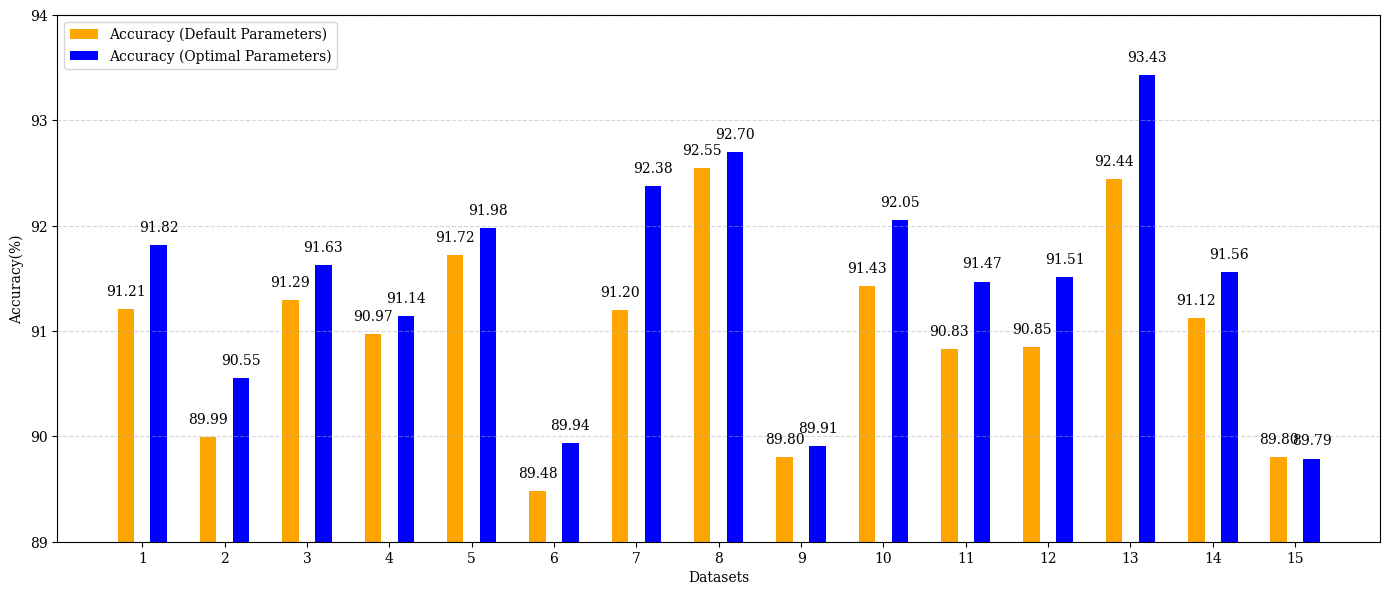

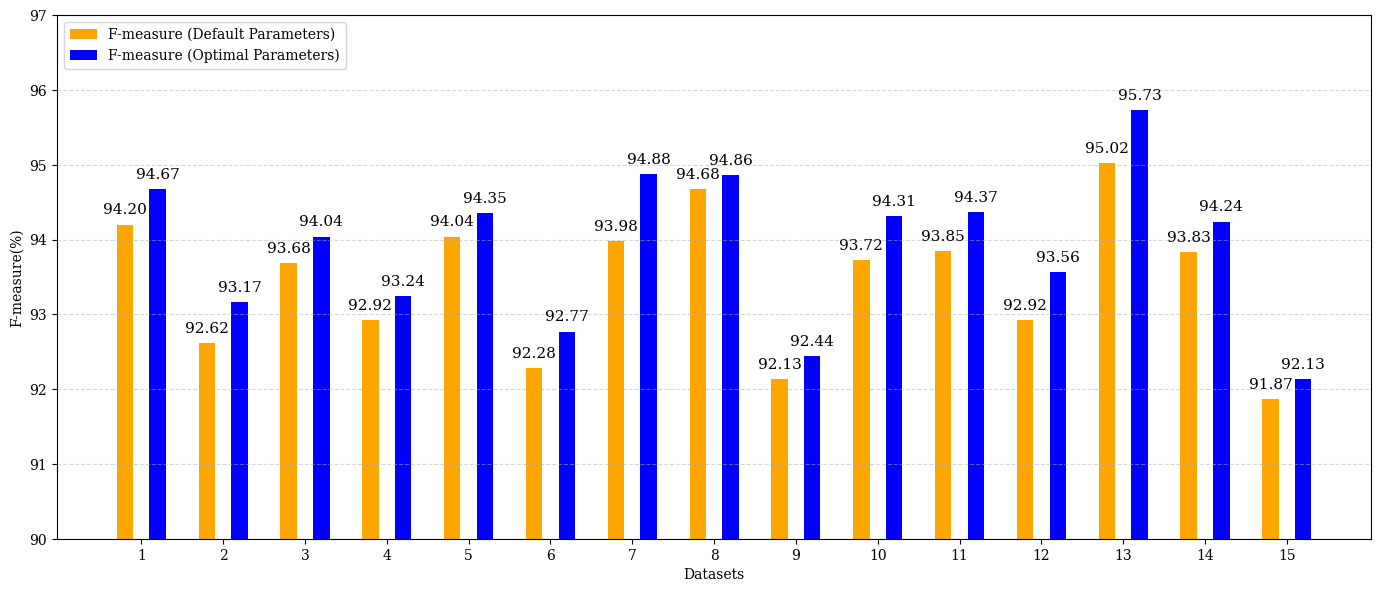

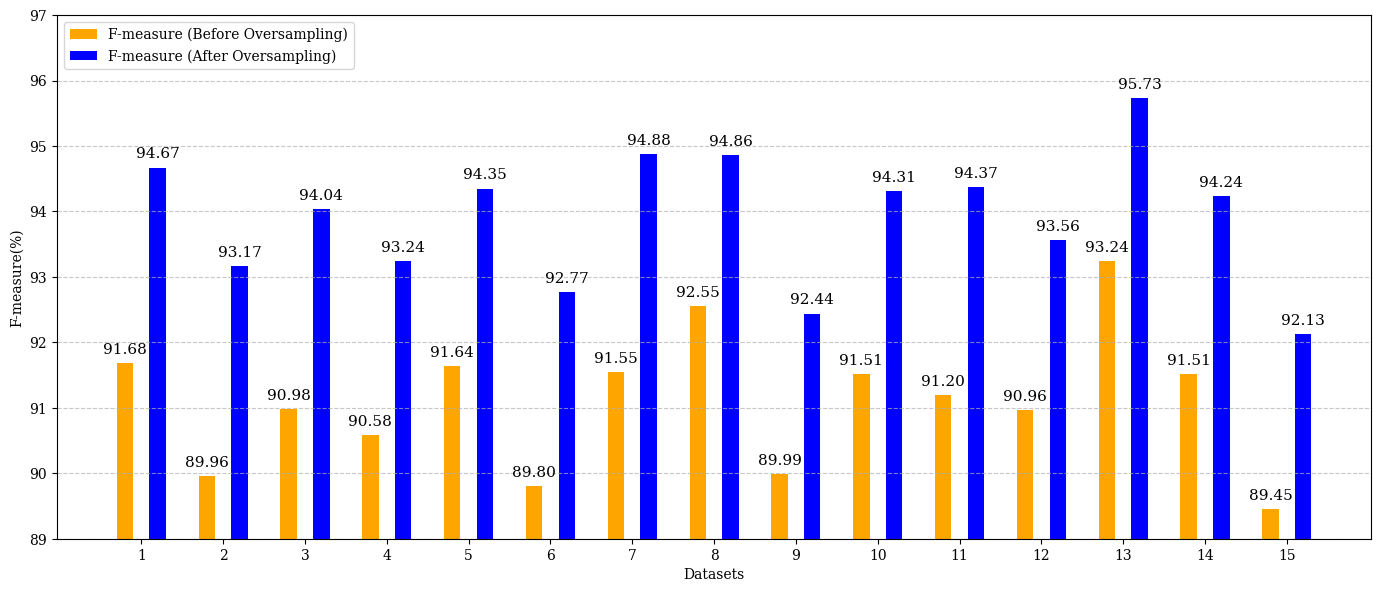

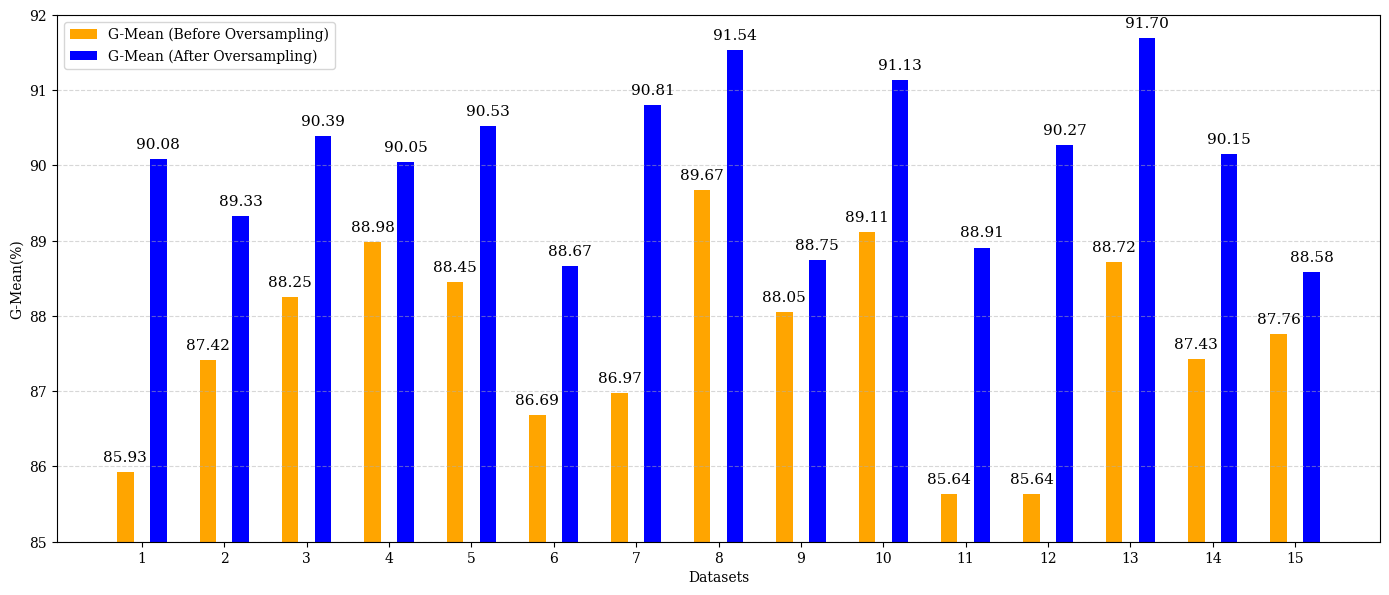

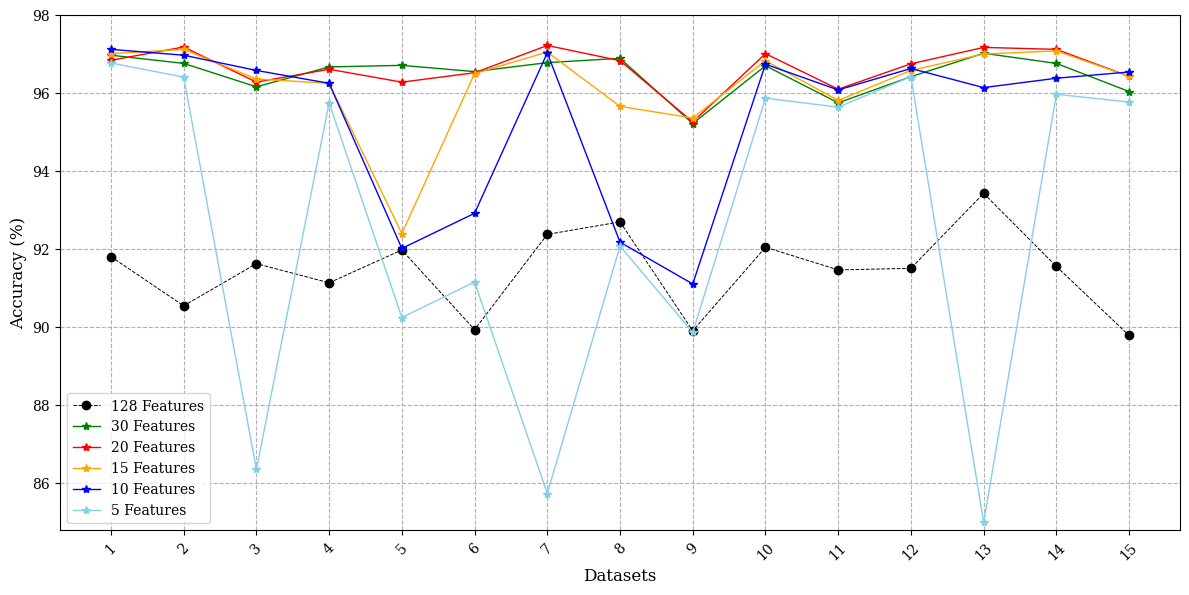

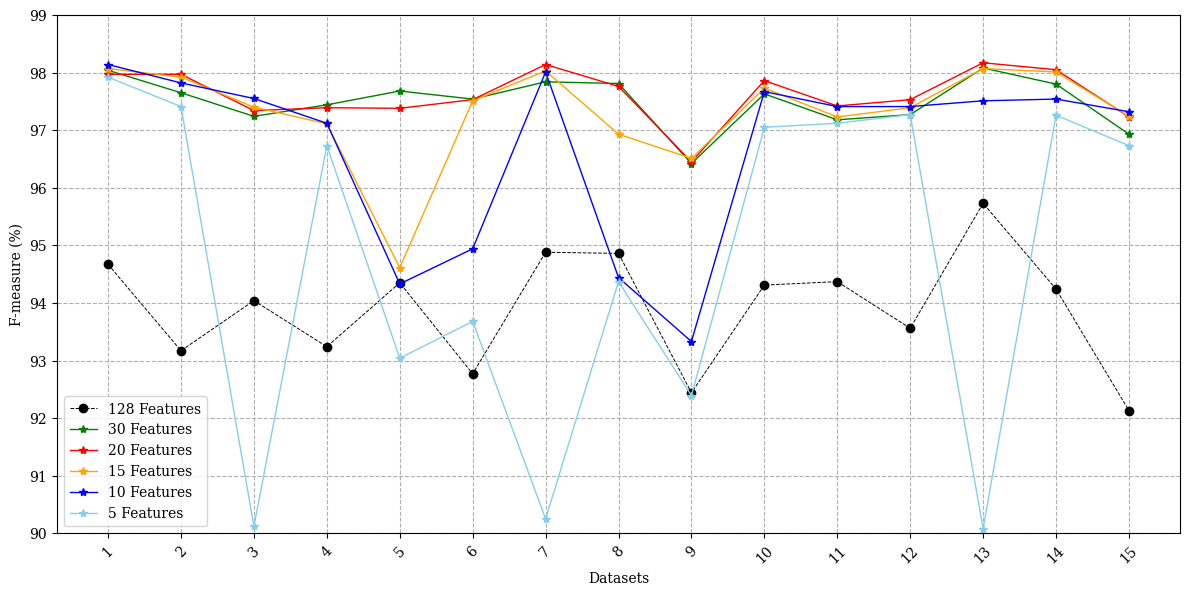

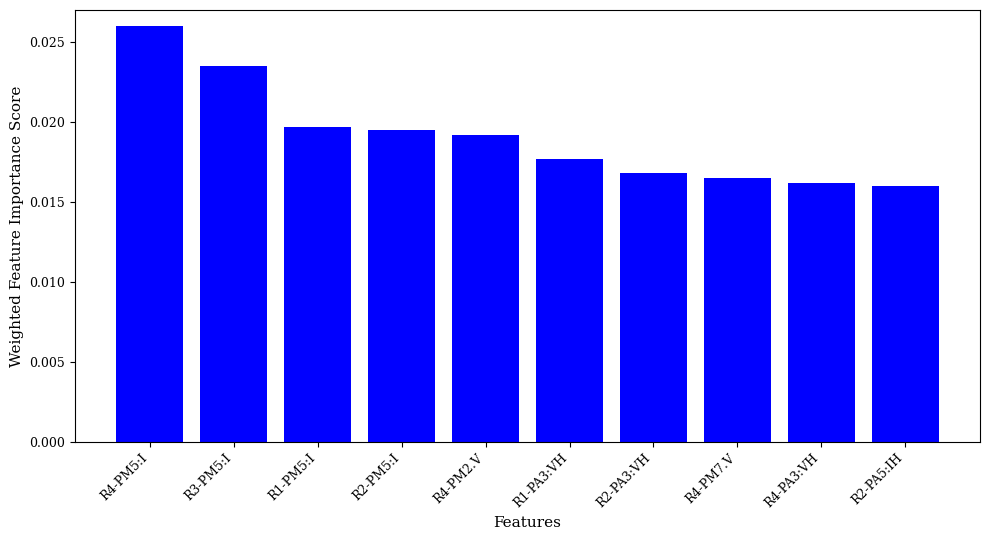

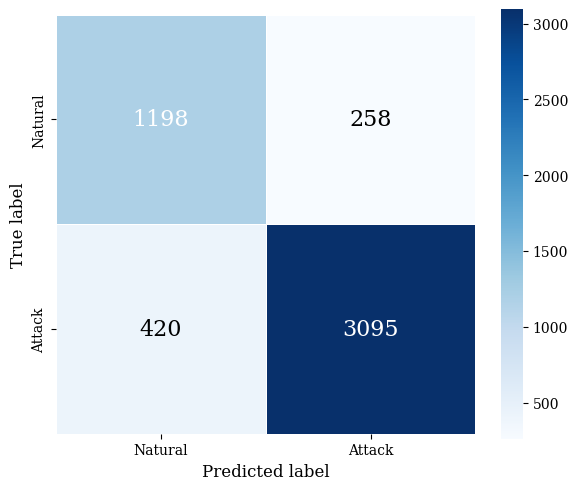

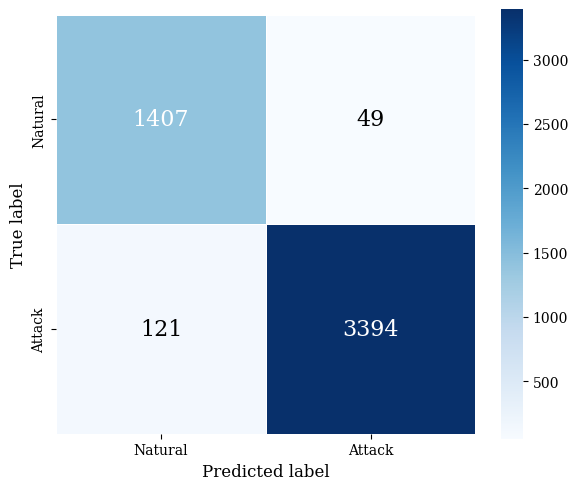

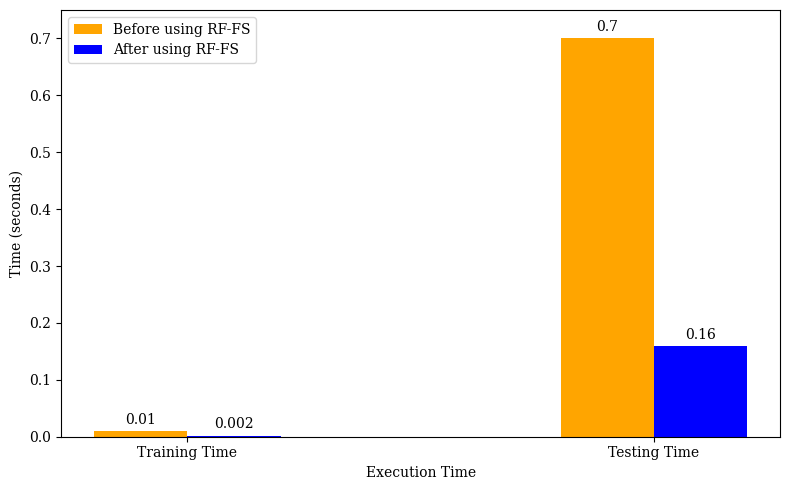

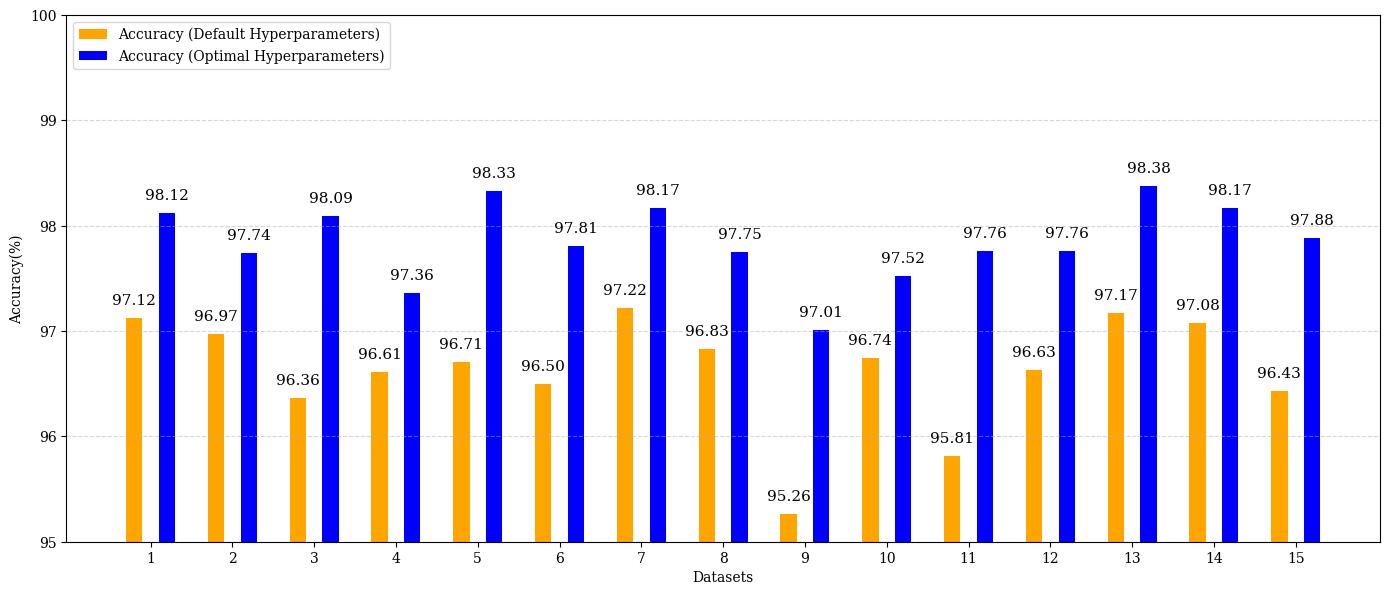

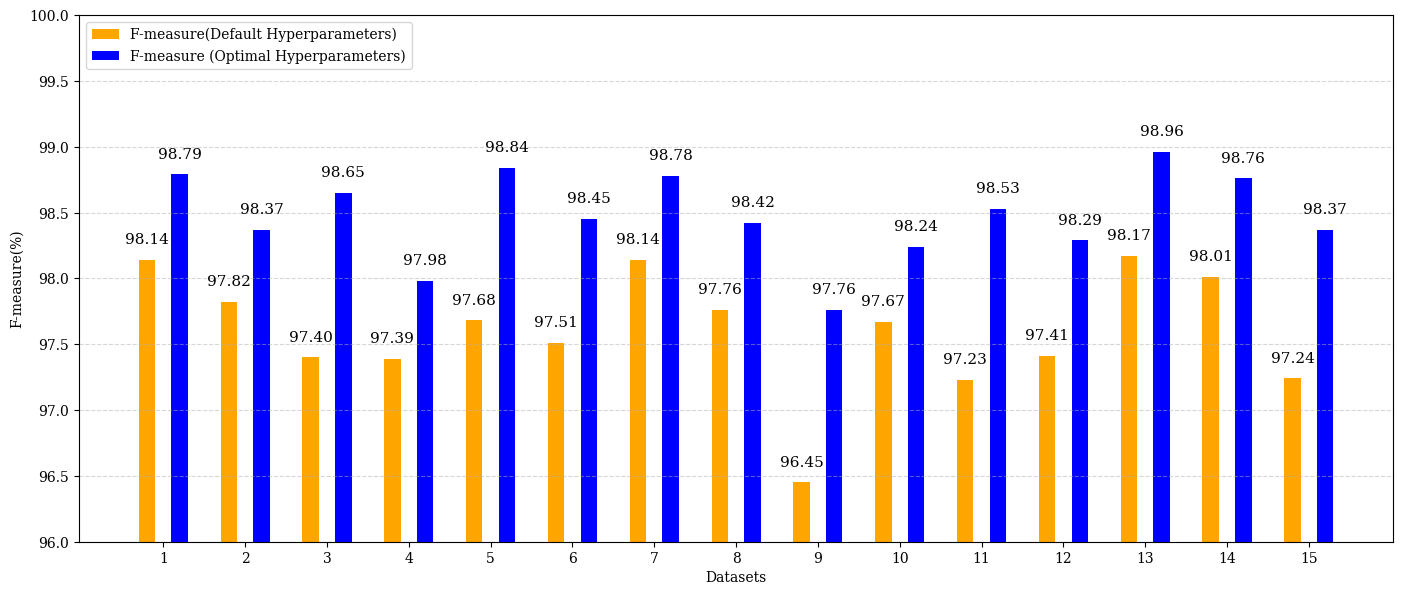

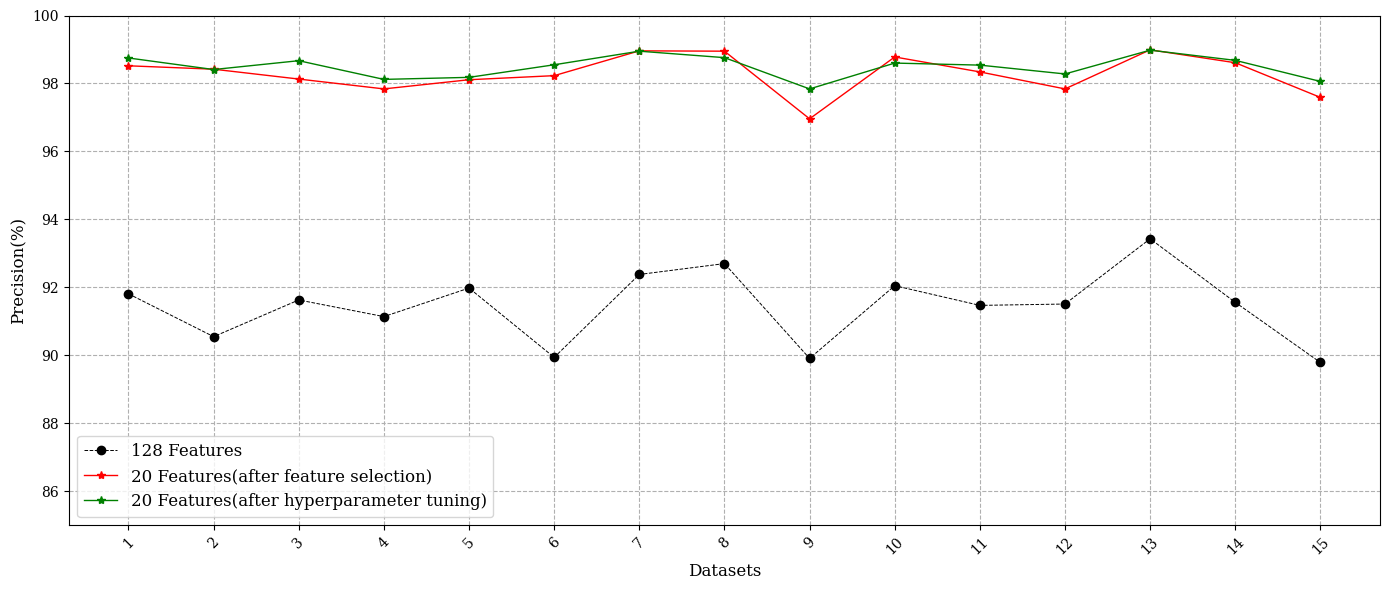

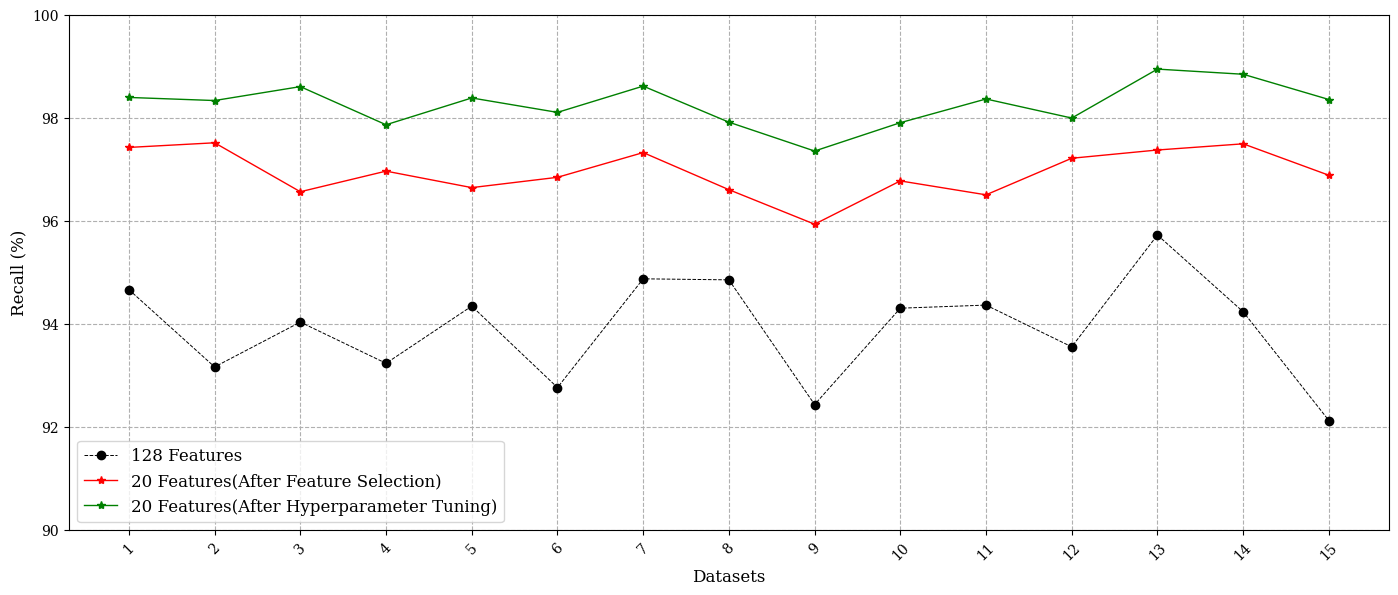

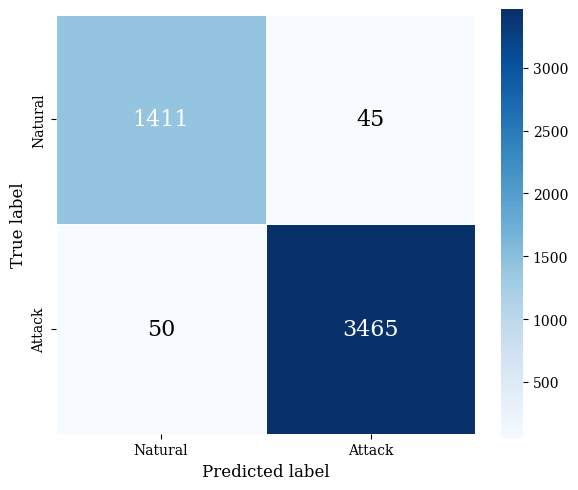

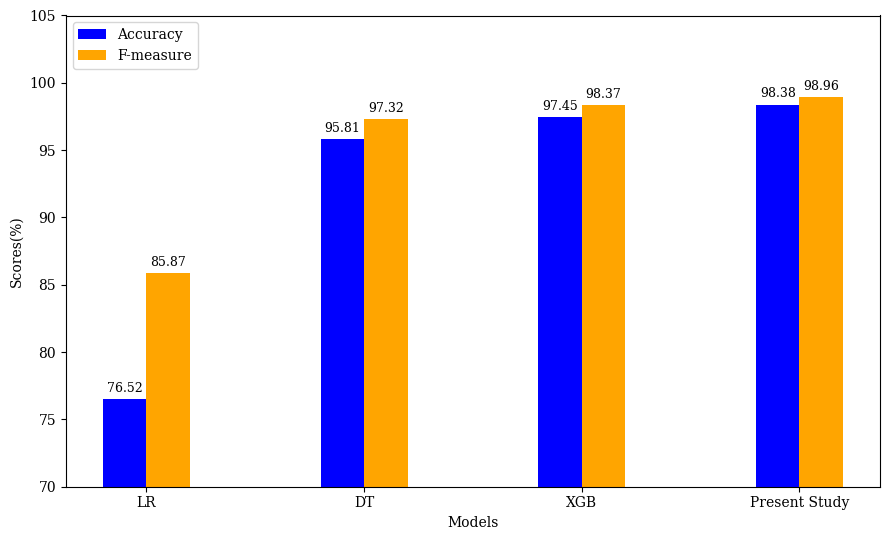

In [30]:
# ploting the results
# here we provide all the scripts to plot the figures based on the obtained results

# --------------------for figure 6----------------------
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# Set Times New Roman as default font
mpl.rcParams['font.family'] = 'DejaVu Serif'

# Data
accuracy_default = [91.21, 89.99, 91.29, 90.97, 91.72, 89.48, 91.20, 92.55,89.80, 91.43, 90.83, 90.85, 92.44, 91.12, 89.80]
# f1_score_default = [94.20, 92.62, 93.68, 92.92, 94.04, 92.28, 93.98, 94.68, 93.72, 93.85, 92.92, 95.02, 93.83, 91.87]
accuracy_optimized = [91.82, 90.55, 91.63, 91.14, 91.98, 89.94, 92.38, 92.70, 89.91, 92.05, 91.47, 91.51, 93.43, 91.56,89.79]
# f1_score_optimized = [94.67, 93.17, 94.04, 93.24, 94.35, 92.77, 94.88, 94.86, 92.44, 94.31, 94.37, 93.56, 95.73, 94.24]


datasets = list(range(1, 16))  # Datasets 1-15

# Bar chart parameters
bar_width = 0.2
x = np.arange(len(datasets))

plt.figure(figsize=(14, 6))
ax = plt.gca()

# Plot bars
bar1 = ax.bar(x - bar_width, accuracy_default, width=bar_width, label='Accuracy (Default Parameters)', color='orange')
# bar2 = ax.bar(x, f1_score_default, width=bar_width, label='F1-Score (Default)', color='orange')
bar3 = ax.bar(x + bar_width, accuracy_optimized, width=bar_width, label='Accuracy (Optimal Parameters)', color='blue')
# bar4 = ax.bar(x + 2 * bar_width, f1_score_optimized, width=bar_width, label='F1-Score (Optimized)', color='red')


for bar_group in [bar1, bar3]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10,rotation = 'horizontal',visible=True,alpha=1)

# Customize plot
plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('Accuracy(%)')
# plt.title('Accuracy performance using Default and Optimized parametres of SVMSMOTE technique')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(89, 94)
plt.savefig('Fig_6_accuracy_comparison.svg', format='svg', dpi=1000, bbox_inches='tight') 
plt.show()

# --------------------for figure 7----------------------


import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# Set Times New Roman as default font
mpl.rcParams['font.family'] = 'DejaVu Serif'

# Data
# accuracy_default = [91.21, 89.99, 91.29, 90.97, 91.72, 89.48, 91.20, 92.55,89.80, 91.43, 90.83, 90.85, 92.44, 91.12, 89.80]
f1_score_default = [94.20, 92.62, 93.68, 92.92, 94.04, 92.28, 93.98, 94.68,92.13, 93.72, 93.85, 92.92, 95.02, 93.83, 91.87]
# accuracy_optimized = [91.92, 90.52, 91.81, 90.80, 91.96, 89.92, 91.97, 92.64, 89.93, 92.21, 91.31, 91.18, 93.57, 91.82,89.84]
f1_score_optimized = [94.67, 93.17, 94.04, 93.24, 94.35, 92.77, 94.88, 94.86, 92.44, 94.31, 94.37, 93.56, 95.73, 94.24,92.13]

datasets = list(range(1, 16))  

# Bar chart parameters
bar_width = 0.2
x = np.arange(len(datasets))

plt.figure(figsize=(14, 6))
ax = plt.gca()

# Plot bars
# bar1 = ax.bar(x - bar_width, accuracy_default, width=bar_width, label='Accuracy (Default)', color='orange')
bar2 = ax.bar(x - bar_width, f1_score_default, width=bar_width, label='F-measure (Default Parameters)', color='orange')
# bar3 = ax.bar(x + bar_width, accuracy_optimized, width=bar_width, label='Accuracy (Optimized)', color='blue')
bar4 = ax.bar(x + bar_width, f1_score_optimized, width=bar_width, label='F-measure (Optimal Parameters)', color='blue')

# Annotate bars with values
for bar_group in [bar2, bar4]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=11,rotation = 'horizontal',visible=True,alpha=1)


# Customize plot
plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('F-measure(%)')
# plt.title('F1-score performance using Default and Optimized parametres of SVMSMOTE technique')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(90, 97)
plt.savefig('Fig_7_F_measure.svg', format='svg', dpi=1000, bbox_inches='tight') 
plt.show()

# --------------------for figure 8----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# Set Times New Roman as default font
mpl.rcParams['font.family'] = 'DejaVu Serif'

# Data
before_svmmote=[91.68, 89.96, 90.98, 90.58, 91.64, 89.80, 91.55, 92.55, 89.99, 91.51, 91.20, 90.96, 93.24, 91.51, 89.45]
after_svmsmote=[94.67, 93.17, 94.04, 93.24, 94.35, 92.77, 94.88, 94.86, 92.44, 94.31, 94.37, 93.56, 95.73, 94.24, 92.13]

datasets = list(range(1, 16))  

# Bar chart parameters
bar_width = 0.2
x = np.arange(len(datasets))

plt.figure(figsize=(14, 6))
ax = plt.gca()

# Plot bars
# bar1 = ax.bar(x - bar_width, accuracy_default, width=bar_width, label='Accuracy (Default)', color='orange')
bar2 = ax.bar(x - bar_width, before_svmmote, width=bar_width, label='F-measure (Before Oversampling)', color='orange')
# bar3 = ax.bar(x + bar_width, accuracy_optimized, width=bar_width, label='Accuracy (Optimized)', color='blue')
bar4 = ax.bar(x + bar_width, after_svmsmote, width=bar_width, label='F-measure (After Oversampling)', color='blue')

# Annotate bars with values
for bar_group in [bar2, bar4]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=11, rotation = 'horizontal',visible=True,alpha=1)

# Customize plot
plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('F-measure(%)')
# plt.title('F1-score performance using Default and Optimized parametres of SVMSMOTE technique')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(89, 97)
plt.savefig('Fig-8-F-measure.svg', format='svg', dpi=1000, bbox_inches='tight') # Save as EPS
plt.show()

# --------------------for figure 9----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'

# Data
before_svmmote=[85.93, 87.42, 88.25, 88.98, 88.45, 86.69, 86.97, 89.67, 88.05, 89.11, 85.64, 85.64, 88.72, 87.43, 87.76]
after_svmsmote=[90.08, 89.33, 90.39, 90.05, 90.53, 88.67, 90.81, 91.54, 88.75, 91.13, 88.91, 90.27, 91.70, 90.15, 88.58]

datasets = list(range(1, 16))  

# Bar chart parameters
bar_width = 0.2
x = np.arange(len(datasets))

plt.figure(figsize=(14, 6))
ax = plt.gca()

# Plot bars
# bar1 = ax.bar(x - bar_width, accuracy_default, width=bar_width, label='Accuracy (Default)', color='orange')
bar2 = ax.bar(x - bar_width, before_svmmote, width=bar_width, label='G-Mean (Before Oversampling)', color='orange')
# bar3 = ax.bar(x + bar_width, accuracy_optimized, width=bar_width, label='Accuracy (Optimized)', color='blue')
bar4 = ax.bar(x + bar_width, after_svmsmote, width=bar_width, label='G-Mean (After Oversampling)', color='blue')

# Annotate bars with values
for bar_group in [bar2, bar4]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=11, rotation = 'horizontal',visible=True,alpha=1)

# Customize plot
plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('G-Mean(%)')
# plt.title('F1-score performance using Default and Optimized parametres of SVMSMOTE technique')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(85, 92)
plt.savefig('Fig_9-G-Mean.svg', format='svg', dpi=1000, bbox_inches='tight') 
plt.show()

# --------------------for figure 10----------------------
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# Set Times New Roman as default font
mpl.rcParams['font.family'] = 'DejaVu Serif'


datasets = [f"{i+1}" for i in range(15)]
five_features =  [96.77, 96.41, 86.36, 95.75, 90.25, 91.16, 85.74, 92.08, 89.87, 95.87, 95.64, 96.42, 85.00, 95.97, 95.77]
ten_features = [97.12, 96.97, 96.58, 96.25, 92.02, 92.92, 97.03, 92.18, 91.11, 96.74, 96.08, 96.63, 96.14, 96.38, 96.54]
fifeteen_features = [97.01, 97.12, 96.36, 96.25, 92.40, 96.50, 97.05, 95.66, 95.36, 96.83, 95.81, 96.58, 97.00, 97.08, 96.43]
twenty_features = [96.84, 97.18, 96.28, 96.61, 96.28, 96.52, 97.22, 96.83, 95.26, 97.01, 96.10, 96.75, 97.17, 97.12, 96.43]
thirty_features = [96.97, 96.76, 96.16, 96.67, 96.71, 96.55, 96.78, 96.89, 95.22, 96.70, 95.75, 96.42, 97.02, 96.76, 96.04]
onehtwenty8_faetures= [91.81,90.55,91.63,91.14,91.98,89.94,92.38,92.70,89.91,92.05,91.47,91.51,93.43,91.56,89.79]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(datasets, onehtwenty8_faetures, marker='o', label='128 Features', linestyle='--', color='black', linewidth=0.7)
plt.plot(datasets, thirty_features, marker='*', label='30 Features', linestyle='-', color='green', linewidth=1)
plt.plot(datasets, twenty_features, marker='*', label='20 Features', linestyle='-', color='red', linewidth=1)
plt.plot(datasets, fifeteen_features, marker='*', label='15 Features', linestyle='-', color='orange', linewidth=1)
plt.plot(datasets, ten_features, marker='*', label='10 Features', linestyle='-', color='blue', linewidth=1)
plt.plot(datasets, five_features, marker='*', label='5 Features', linestyle='-', color='skyblue', linewidth=1)


# Add labels, title, and legend
plt.xlabel("Datasets", fontsize=12)
plt.ylabel("Accuracy (%)",fontsize=12)
# plt.title("Accuracy performance Before and After Using feature selection")
plt.grid(True, linestyle='--', alpha=1)
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.ylim(84.80, 98)
plt.savefig('Fig_10_Accuracy_performance.svg', format='svg', dpi=1000, bbox_inches='tight') 
# Show the plot
plt.show()

# --------------------for figure 11----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Serif'


datasets = [f"{i+1}" for i in range(15)]
five_features = [97.92, 97.41, 90.12, 96.73, 93.04, 93.68, 90.25, 94.37, 92.39, 97.05, 97.12, 97.27, 90.08, 97.26, 96.73]
ten_features = [98.14, 97.82, 97.55, 97.12, 94.33, 94.94, 98.01, 94.44, 93.33, 97.67, 97.41, 97.41, 97.51, 97.54, 97.32]
fifeteen_features = [98.07, 97.92, 97.40, 97.11, 94.61, 97.51, 98.03, 96.93, 96.51, 97.73, 97.23, 97.39, 98.07, 98.01, 97.24]
twenty_features = [97.97, 97.97, 97.34, 97.39, 97.38, 97.53, 98.14, 97.76, 96.45, 97.86, 97.42, 97.53, 98.17, 98.05, 97.23]
thirty_features = [98.04, 97.65, 97.24, 97.44, 97.68, 97.54, 97.84, 97.81, 96.42, 97.63, 97.18, 97.27, 98.08, 97.80, 96.93]
onehtwenty8_faetures= [94.67,93.17,94.04,93.24,94.35,92.77,94.88,94.86,92.44,94.31,94.37,93.56,95.73,94.24,92.13]



# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(datasets, onehtwenty8_faetures, marker='o', label='128 Features', linestyle='--', color='black', linewidth=0.7)
plt.plot(datasets, thirty_features, marker='*', label='30 Features', linestyle='-', color='green', linewidth=1)
plt.plot(datasets, twenty_features, marker='*', label='20 Features', linestyle='-', color='red', linewidth=1)
plt.plot(datasets, fifeteen_features, marker='*', label='15 Features', linestyle='-', color='orange', linewidth=1)
plt.plot(datasets, ten_features, marker='*', label='10 Features', linestyle='-', color='blue', linewidth=1)
plt.plot(datasets, five_features, marker='*', label='5 Features', linestyle='-', color='skyblue', linewidth=1)


# Add labels, title, and legend
plt.xlabel("Datasets")
plt.ylabel("F-measure (%)")
# plt.title("F1-score performance Before and After Using feature selection")
plt.grid(True, linestyle='--', alpha=1)
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.ylim(90, 99)
plt.savefig('Fig_11_F-measure_performance.svg', format='svg', dpi=1000, bbox_inches='tight') 
plt.show()

# --------------------for figure 12----------------------

import matplotlib.pyplot as plt
import numpy as np

# Feature names based on WFI
features = [
    'R4-PM5:I', 'R3-PM5:I', 'R1-PM5:I', 'R2-PM5:I', 'R4-PM2.V',
    'R1-PA3:VH', 'R2-PA3:VH', 'R4-PM7.V', 'R4-PA3:VH', 'R2-PA5:IH'
]


# Approximate Weighted Feature Importance Scores (from the figure)
scores = [0.0260, 0.0235, 0.0197, 0.0195, 0.0192,
          0.0177, 0.0168, 0.0165, 0.0162, 0.0160]

# Create figure
plt.figure(figsize=(10, 5.5))

# Plot bars
bars = plt.bar(features, scores, color='blue', width=0.8)

# Labels and title style
plt.ylabel('Weighted Feature Importance Score', fontsize=11)
plt.xlabel('Features', fontsize=11)

# Rotate x-tick labels for readability
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

# Set y-axis limits to match the figure
plt.ylim(0, 0.027)

plt.tight_layout()
plt.show()

# --------------------for figure 13----------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values
cm = np.array([[1198, 258],
               [420, 3095]])

# Labels
labels = ['Natural', 'Attack']

# Create figure
plt.figure(figsize=(6, 5))

# Plot heatmap
ax = sns.heatmap(cm, 
                 annot=True, 
                 fmt='d', 
                 cmap='Blues',         
                 cbar=True,
                 square=True,
                 linewidths=0.5,
                 linecolor='white',
                 annot_kws={"size": 16,  "color": "white"},
                 xticklabels=labels,
                 yticklabels=labels)


for text in ax.texts:
    value = int(text.get_text())
    if value < 1000:          
        text.set_color('black')
    else:                     
        text.set_color('white')

# Labels
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# --------------------for figure 14----------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values
cm = np.array([[1407, 49],
               [121, 3394]])

# Labels
labels = ['Natural', 'Attack']

# Create figure
plt.figure(figsize=(6, 5))

# Plot heatmap
ax = sns.heatmap(cm, 
                 annot=True, 
                 fmt='d', 
                 cmap='Blues',         
                 cbar=True,
                 square=True,
                 linewidths=0.5,
                 linecolor='white',
                 annot_kws={"size": 16,  "color": "white"},
                 xticklabels=labels,
                 yticklabels=labels)


for text in ax.texts:
    value = int(text.get_text())
    if value < 1000:          # light cells → black text
        text.set_color('black')
    else:                     # dark cells → white text
        text.set_color('white')

# Labels
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# --------------------for figure 15----------------------

import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['Training Time', 'Testing Time']
before = [0.01, 0.7]
after  = [0.002, 0.16]

x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, before, width, label='Before using RF-FS', color='orange')  
bars2 = ax.bar(x + width/2, after,  width, label='After using RF-FS',  color='blue') 

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Time (seconds)')
ax.set_xlabel('Execution Time')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 0.75)
ax.legend(loc='upper left')


plt.tight_layout()
plt.show()

# --------------------for figure 16----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# Set Times New Roman as default font
mpl.rcParams['font.family'] = 'DejaVu Serif'

# results
datasets = np.arange(1, 16)
accuracy_feature_selection = [97.12, 96.97, 96.36, 96.61, 96.71, 96.50, 97.22, 96.83, 95.26, 96.74, 95.81, 96.63, 97.17, 97.08, 96.43]
accuracy_optuna = [98.12, 97.74, 98.09, 97.36, 98.33, 97.81, 98.17, 97.75, 97.01, 97.52, 97.76, 97.76, 98.38, 98.17, 97.88]

# Plotting bar charts
bar_width = 0.2
x = np.arange(len(datasets))

plt.figure(figsize=(14, 6))
ax = plt.gca()

# Bar positions
bar1 = ax.bar(x - bar_width, accuracy_feature_selection, width=bar_width, label='Accuracy (Default Hyperparameters)', color='orange')
bar3 = ax.bar(x + bar_width, accuracy_optuna, width=bar_width, label='Accuracy (Optimal Hyperparameters)', color='blue')


for bar_group in [bar1, bar3]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=11,rotation = 'horizontal',visible=True,alpha=1)

# Customize plot
plt.xticks(x, datasets) 
plt.xlabel('Datasets')
plt.ylabel('Accuracy(%)')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(95, 100)
plt.savefig('Fig_16_KNN_model_accuracy.svg', format='svg', dpi=1000, bbox_inches='tight') # Save as EPS
plt.show()

# --------------------for figure 117----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'

# Sample data
datasets = np.arange(1, 16)
f1_score_feature_selection = [98.14, 97.82, 97.40, 97.39, 97.68, 97.51, 98.14, 97.76, 96.45, 97.67, 97.23, 97.41, 98.17, 98.01, 97.24]
f1_score_optuna = [98.79, 98.37, 98.65, 97.98, 98.84, 98.45, 98.78, 98.42, 97.76, 98.24, 98.53, 98.29, 98.96, 98.76, 98.37]

# Plotting bar charts
bar_width = 0.2
x = np.arange(len(datasets))

plt.figure(figsize=(14, 6))
ax = plt.gca()

# Bar positions
# bar1 = ax.bar(x - bar_width, accuracy_feature_selection, width=bar_width, label='Accuracy (Feature Selection)', color='blue')
bar2 = ax.bar(x - bar_width, f1_score_feature_selection, width=bar_width, label='F-measure(Default Hyperparameters)', color='orange')
# bar3 = ax.bar(x + bar_width, accuracy_optuna, width=bar_width, label='Accuracy (Optuna)', color='orange')
bar4 = ax.bar(x + bar_width, f1_score_optuna, width=bar_width, label='F-measure (Optimal Hyperparameters)', color='blue')


for bar_group in [bar2, bar4]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=11,rotation = 'horizontal',visible=True,alpha=1)

# Customize plot
plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('F-measure(%)')
# plt.title('F1-score comparison of Feature Selection and Optuna Optimization')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(96, 100)
plt.savefig('Fig_17_KNN_model_F-measure.svg', format='svg', dpi=1000, bbox_inches='tight') 
plt.show()

# --------------------for figure 18----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl


mpl.rcParams['font.family'] = 'DejaVu Serif'

datasets = [f"{i+1}" for i in range(15)]
original_precision = [91.81, 90.55, 91.63, 91.14, 91.98, 89.94, 92.38, 92.70, 89.91, 92.05, 91.47, 91.51, 93.43, 91.56, 89.79]
feature_selection_precision = [98.52, 98.42, 98.13, 97.84, 98.11, 98.23, 98.96, 98.95, 96.96, 98.78, 98.34, 97.84, 98.99, 98.61, 97.59]
hyperparameter_tuning_precision = [98.75, 98.41, 98.67, 98.12, 98.18, 98.55, 98.95, 98.76, 97.84, 98.60, 98.54, 98.28, 98.98, 98.68, 98.06]


# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(datasets, original_precision , marker='o', label='128 Features', linestyle='--', color='black', linewidth=0.7)
plt.plot(datasets, feature_selection_precision, marker='*', label='20 Features(after feature selection)', linestyle='-', color='red', linewidth=1)
plt.plot(datasets, hyperparameter_tuning_precision, marker='*', label='20 Features(after hyperparameter tuning)', linestyle='-', color='green', linewidth=1)


# Add labels, title, and legend
plt.xlabel("Datasets",fontsize= 12)
plt.ylabel("Precision(%)",fontsize= 12)
# plt.title("Precision performance Before and After Using feature selection and hyperparameter_tuning")
plt.grid(True, linestyle='--', alpha=1)
plt.legend(loc='lower left')
plt.legend(fontsize= 12)
plt.ylim(85, 100)
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.savefig('accuracy_comparison.png', dpi=1000) 
plt.savefig('Fig_18_Precision_performance.svg', format='svg', dpi=1000, bbox_inches='tight') 
# Show the plot
plt.show()

# --------------------for figure 19----------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
# Set Times New Roman as default font
mpl.rcParams['font.family'] = 'DejaVu Serif'

# Sample accuracy data (replace with your actual data)
datasets = [f"{i+1}" for i in range(15)]
original_recall = [94.67, 93.17, 94.04, 93.24, 94.35, 92.77, 94.88, 94.86, 92.44, 94.31, 94.37, 93.56, 95.73, 94.24, 92.13]
feature_selection_recall = [97.43, 97.52, 96.57, 96.97, 96.65, 96.85, 97.33, 96.61, 95.94, 96.78, 96.51, 97.22, 97.38, 97.50, 96.89]
hyperparameter_tuning_recall = [98.40, 98.34, 98.61, 97.87, 98.39, 98.11, 98.62, 97.92, 97.36, 97.91, 98.37, 98.00, 98.95, 98.85, 98.36]

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(datasets, original_recall , marker='o', label='128 Features', linestyle='--', color='black', linewidth=0.7)
plt.plot(datasets, feature_selection_recall, marker='*', label='20 Features(After Feature Selection)', linestyle='-', color='red', linewidth=1)
plt.plot(datasets, hyperparameter_tuning_recall, marker='*', label='20 Features(After Hyperparameter Tuning)', linestyle='-', color='green', linewidth=1)


# Add labels, title, and legend
plt.xlabel("Datasets",fontsize= 12)
plt.ylabel("Recall (%)",fontsize= 12)
# plt.title("Recall performance after using feature selection and hyperparameter tuning")
plt.grid(True, linestyle='--', alpha=1)
plt.legend(fontsize= 12)
plt.xticks(rotation=45)  
plt.tight_layout() 
plt.ylim(90, 100)
plt.savefig('Fig-19-Recall-performance.svg', format='svg', dpi=1000, bbox_inches='tight') 
# Show the plot
plt.show()

# --------------------for figure 20----------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values
cm = np.array([[1411, 45],
               [50, 3465]])

# Labels
labels = ['Natural', 'Attack']

# Create figure
plt.figure(figsize=(6, 5))

# Plot heatmap
ax = sns.heatmap(cm, 
                 annot=True, 
                 fmt='d', 
                 cmap='Blues',         
                 cbar=True,
                 square=True,
                 linewidths=0.5,
                 linecolor='white',
                 annot_kws={"size": 16,  "color": "white"},
                 xticklabels=labels,
                 yticklabels=labels)

for text in ax.texts:
    value = int(text.get_text())
    if value < 1000:         
        text.set_color('black')
    else:                  
        text.set_color('white')

# Labels
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# --------------------for figure 21----------------------

import matplotlib.pyplot as plt
import numpy as np

# results
models = ['LR', 'DT', 'XGB', 'Present Study']
accuracy  = [76.52, 95.81, 97.45, 98.38]
fmeasure  = [85.87, 97.32, 98.37, 98.96]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5.5))

bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy',  color='blue')  
bars2 = ax.bar(x + width/2, fmeasure, width, label='F-measure', color='orange')  

# value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Scores(%)')
ax.set_xlabel('Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(70, 105)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

n_features = X_train.shape[1]


# Reshape for sequential models

# LSTM / GRU : (samples, timesteps=1, features)
X_train_seq = X_train.reshape((X_train.shape[0], 1, n_features))
X_test_seq  = X_test.reshape((X_test.shape[0], 1, n_features))

# CNN-LSTM / CNN-GRU : (samples, features, 1)
X_train_cnn = X_train.reshape((X_train.shape[0], n_features, 1))
X_test_cnn  = X_test.reshape((X_test.shape[0], n_features, 1))


def create_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        GRU(32),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_cnn_gru(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        GRU(50),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


# training the models 

# Options:
# model = create_lstm(input_shape=(1, n_features))
# model = create_gru(input_shape=(1, n_features))
model = create_cnn_lstm(input_shape=(n_features, 1))
# model = create_cnn_gru(input_shape=(n_features, 1))   

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


if isinstance(model.layers[0], (LSTM, GRU)):
    X_tr, X_te = X_train_seq, X_test_seq
else:
    X_tr, X_te = X_train_cnn, X_test_cnn

history = model.fit(
    X_tr, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# Evaluation

y_pred_proba = model.predict(X_te)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("\n" + "="*55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print("="*55)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))